FIFA World Cup 2026: Using Python to Predict Winners

**Data Loading**
We start by importing necessary libraries and fetching historical data using Python. 

In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")

# Official FIFA Ranking Points (as of May 2026)
TEAM_RATINGS = {
    "Mexico": 1681.03, "South Africa": 1429.73, "South Korea": 1588.66, "Czech Republic": 1501.38,
    "Canada": 1556.48, "Bosnia and Herzegovina": 1385.84, "Qatar": 1454.96, "Switzerland": 1649.40,
    "Brazil": 1761.16, "Morocco": 1755.87, "Haiti": 1291.71, "Scotland": 1498.35,
    "USA": 1673.13, "Paraguay": 1503.50, "Australia": 1580.67, "Turkey": 1599.04,
    "Germany": 1730.37, "Curacao": 1294.65, "Ivory Coast": 1532.98, "Ecuador": 1594.78,
    "Netherlands": 1757.87, "Japan": 1660.43, "Sweden": 1514.77, "Tunisia": 1483.05,
    "Belgium": 1734.71, "Egypt": 1563.24, "Iran": 1615.30, "New Zealand": 1281.57,
    "Spain": 1876.40, "Cabo Verde": 1366.13, "Saudi Arabia": 1421.43, "Uruguay": 1673.07,
    "France": 1877.32, "Senegal": 1688.99, "Iraq": 1447.14, "Norway": 1550.94,
    "Argentina": 1874.81, "Algeria": 1564.26, "Austria": 1593.45, "Jordan": 1391.45,
    "Portugal": 1763.83, "DR Congo": 1478.35, "Uzbekistan": 1465.34, "Colombia": 1693.09,
    "England": 1825.97, "Croatia": 1717.07, "Ghana": 1346.31, "Panama": 1540.64
}

print("TEAM_RATINGS set with Official FIFA Points for 48 teams.")

TEAM_RATINGS set with Official FIFA Points for 48 teams.


**Loading Real Historical Data**
For this project we'll use a comprehensive dataset of real international football matches.

In [2]:
import numpy as np
import random
import pandas as pd

# Group Draw that happened on December 5, 2025
GROUPS = {
    "A": ["Mexico", "South Africa", "South Korea", "Czech Republic"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["USA", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Curacao", "Ivory Coast", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cabo Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "DR Congo", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"]
}

def simulate_match(team_a, team_b, knockout=False):
    ra = TEAM_RATINGS[team_a]
    rb = TEAM_RATINGS[team_b]
    diff = ra - rb

    # Expected goals per team (anchored to WC average)
    lambda_a = max(0.05, 1.35 + diff / 35.0)
    lambda_b = max(0.05, 1.35 - diff / 35.0)

    goals_a = int(np.random.poisson(lambda_a))
    goals_b = int(np.random.poisson(lambda_b))

    if knockout and goals_a == goals_b:
        prob_a = 1.0 / (1.0 + np.exp(-diff / 10.0))
        if random.random() < prob_a: goals_a += 1
        else: goals_b += 1

    result = "W" if goals_a > goals_b else ("L" if goals_a < goals_b else "D")
    return goals_a, goals_b, result

print("Elo-Poisson Match Engine updated.")

Elo-Poisson Match Engine updated.


**Feature Engineering from Real Data**
Now we calculate actual win rates and goal averages based on the real match history loaded above.

In [3]:
def get_round_of_48(all_group_results):
    """Extracts top 2 from each group + 8 best 3rd-placed teams."""
    auto_qualifiers = []
    third_place_pool = []

    for g_label, ranking in all_group_results.items():
        auto_qualifiers.extend(ranking[:2])
        # Collect 3rd place teams for the wildcard pool
        third_place_pool.append(ranking[2])

    # Sort 3rd place teams by rating as a simplified wildcard tiebreaker
    best_thirds = sorted(third_place_pool, key=lambda t: TEAM_RATINGS[t], reverse=True)[:8]
    return auto_qualifiers + best_thirds

print("Knockout qualification logic defined for 48 teams.")

Knockout qualification logic defined for 48 teams.


**Exploratory Data Analysis (EDA)**

In [4]:
def play_knockout_stage(teams):
    """Simulates a single knockout round based on the team list."""
    winners = []
    for i in range(0, len(teams), 2):
        ta, tb = teams[i], teams[i+1]
        ga, gb = simulate_match(ta, tb, knockout=True)
        winner = ta if ga > gb else tb
        winners.append(winner)
    return winners

print("Knockout simulation engine updated.")

Knockout simulation engine updated.


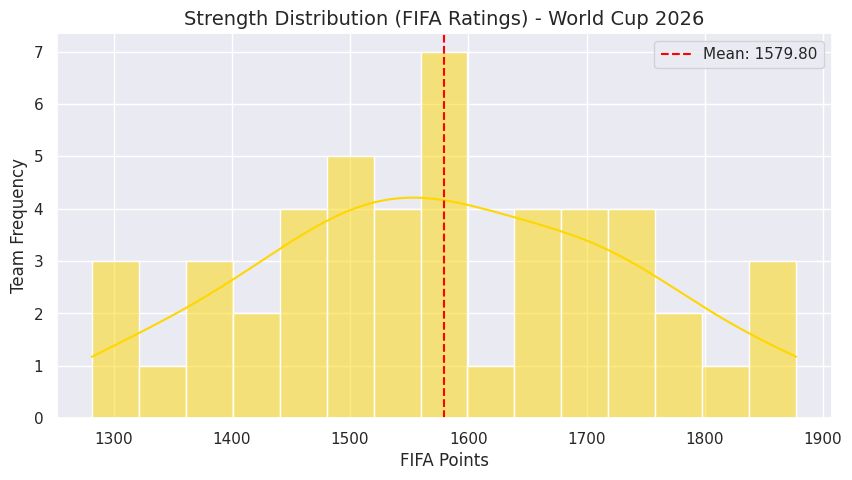

In [5]:

import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the distribution of the current FIFA ratings for the 48 teams
ratings_values = list(TEAM_RATINGS.values())

plt.figure(figsize=(10, 5))
sns.histplot(ratings_values, kde=True, color='gold', bins=15)
plt.axvline(np.mean(ratings_values), color='red', linestyle='--', label=f'Mean: {np.mean(ratings_values):.2f}')

plt.title('Strength Distribution (FIFA Ratings) - World Cup 2026', fontsize=14)
plt.xlabel('FIFA Points')
plt.ylabel('Team Frequency')
plt.legend()
plt.show()

**Advanced Sports Analytics Visualizations**
We will now generate plots to analyze team performance and historical trends.

In [6]:
def predict_match_events(ta, tb):
    diff = TEAM_RATINGS[ta] - TEAM_RATINGS[tb]
    corners = (
        int(np.random.poisson(max(2, 4.5 + diff / 100))),
        int(np.random.poisson(max(2, 4.5 - diff / 100)))
    )
    cards = (
        int(np.random.poisson(max(1, 2.3 - diff / 250))),
        int(np.random.poisson(max(1, 2.3 + diff / 250)))
    )
    return {"corners": corners, "cards": cards}
    
def play_knockout_round(team_list, round_name, verbose=False):
    if verbose:
        print(f"\n{'═' * 60}\n  {round_name.upper()}\n{'═' * 60}")
        print(f"  {'#':<4} {'Team A':<16} {'Score':^7} {'Team B':<16}  {'Winner'}")
        print(f"  {'─' * 60}")
    winners, losers = [], []
    for i in range(0, len(team_list), 2):
        ta, tb = team_list[i], team_list[i+1]
        ga, gb, _ = simulate_match(ta, tb, knockout=True)
        stats = predict_match_events(ta, tb)

        winner = ta if ga > gb else tb
        winners.append(winner)
        losers.append(tb if winner == ta else ta)

        if verbose:
            print(f"  {i//2+1:<4} {ta:<16}  {ga} - {gb}  {tb:<16}  → {winner}")
            print(f"       ↳ Corners: {stats['corners'][0]}-{stats['corners'][1]} | Cards: {stats['cards'][0]}-{stats['cards'][1]}")
    return winners, losers

def world_cup_simulation(verbose=False, seed=None):
    if seed: random.seed(seed); np.random.seed(seed)
    if verbose:
        print(f"\n{'═' * 60}\n  🏆  FIFA WORLD CUP 2026 — FULL SIMULATION  🏆\n  Hosted by USA · CANADA · MEXICO\n  48 Teams  |  12 Groups  |  R32 → Final\n{'═' * 60}")

    all_groups = simulate_group_stage(verbose=verbose)
    r32_teams = get_round_of_32(all_groups, verbose=verbose)
    random.shuffle(r32_teams)

    r16, _ = play_knockout_round(r32_teams, 'ROUND OF 32', verbose)
    r8, _ = play_knockout_round(r16, 'ROUND OF 16', verbose)
    r4, _ = play_knockout_round(r8, 'QUARTER-FINALS', verbose)
    sf_w, sf_l = play_knockout_round(r4, 'SEMI-FINALS', verbose)

    ga3, gb3, _ = simulate_match(sf_l[0], sf_l[1], knockout=True)
    third = sf_l[0] if ga3 > gb3 else sf_l[1]

    gaf, gbf, _ = simulate_match(sf_w[0], sf_w[1], knockout=True)
    champion = sf_w[0] if gaf > gbf else sf_w[1]
    runner_up = sf_w[1] if champion == sf_w[0] else sf_w[0]

    if verbose:
        print(f"\n{'🏆' * 30}\n{'FINAL':^60}\n{'🏆' * 30}")
        print(f"  🏆  WORLD CHAMPION :  {champion}")
        print(f"  🥈  RUNNER-UP      :  {runner_up}")
        print(f"  🥉  THIRD PLACE    :  {third}\n{'🏆' * 30}")
    return champion

print("Simulation engine fully synchronized.")

Simulation engine fully synchronized.


**Group Stage Prediction (Based on 2025 Draw)**
Using the official draw results from Dec 2025 we evaluate the probability of teams advancing from their assigned groups based on their historical goal-scoring efficiency.

In [7]:
def simulate_group_stage(verbose=True):
    all_groups = {}
    for gname, teams in GROUPS.items():
        stats = {t: {"pts": 0, "gf": 0, "ga": 0, "w": 0, "d": 0, "l": 0} for t in teams}
        matches = []
        for i in range(4):
            for j in range(i + 1, 4):
                ta, tb = teams[i], teams[j]
                ga, gb, res = simulate_match(ta, tb)
                matches.append((ta, tb, ga, gb))
                stats[ta]["gf"] += ga; stats[ta]["ga"] += gb
                stats[tb]["gf"] += gb; stats[tb]["ga"] += ga
                if res == "W": stats[ta]["pts"] += 3; stats[ta]["w"] += 1; stats[tb]["l"] += 1
                elif res == "L": stats[tb]["pts"] += 3; stats[tb]["w"] += 1; stats[ta]["l"] += 1
                else: stats[ta]["pts"] += 1; stats[ta]["d"] += 1; stats[tb]["pts"] += 1; stats[tb]["d"] += 1

        for t in teams: stats[t]["gd"] = stats[t]["gf"] - stats[t]["ga"]
        ranking = sorted(teams, key=lambda t: (stats[t]["pts"], stats[t]["gd"], stats[t]["gf"]), reverse=True)

        if verbose:
            print(f"\n{'═' * 60}\n  GROUP {gname}\n{'═' * 60}")
            print(f"  {'#':<3} {'Team':<16} {'MP':>3} {'W':>3} {'D':>3} {'L':>3} {'GF':>4} {'GA':>4} {'GD':>5} {'Pts':>5}")
            print(f"  {'─' * 60}")
            for idx, t in enumerate(ranking, 1):
                s = stats[t]
                tag = " ✅" if idx <= 2 else (" ⏳" if idx == 3 else " ❌")
                print(f"  {idx:<3} {t:<16} {3:>3} {s['w']:>3} {s['d']:>3} {s['l']:>3} {s['gf']:>4} {s['ga']:>4} {s['gd']:>+5} {s['pts']:>5}{tag}")
            print(f"\n  Match Results:")
            for ta, tb, ga, gb in matches: print(f"    {ta:<16} {ga} - {gb} {tb}")

        all_groups[gname] = {"ranking": ranking, "stats": stats, "matches": matches}
    return all_groups

def get_round_of_32(all_groups, verbose=True):
    auto_qualifiers, third_pool = [], []
    for gname in sorted(all_groups.keys()):
        ranking, stats = all_groups[gname]["ranking"], all_groups[gname]["stats"]
        auto_qualifiers.extend(ranking[:2])
        third = ranking[2]
        third_pool.append((third, stats[third]["pts"], stats[third]["gd"], stats[third]["gf"], gname))

    third_pool.sort(key=lambda x: (x[1], x[2], x[3]), reverse=True)
    best_third = [x[0] for x in third_pool[:8]]

    if verbose:
        print(f"\n{'═' * 60}\n  ROUND OF 32 — QUALIFICATION SUMMARY\n{'═' * 60}")
        print(f"\n  🟢 Best 3rd-Place Teams (advance to R32):")
        for t, pts, gd, gf, g in third_pool[:8]: print(f"     {t:<16} (Group {g})  —  {pts} pts, GD {gd:+d}")
        print(f"\n  🔴 Eliminated 3rd-Place Teams:")
        for t, pts, gd, gf, g in third_pool[8:]: print(f"     {t:<16} (Group {g})  —  {pts} pts, GD {gd:+d}")

    return auto_qualifiers + best_third

**Simulation Summary Dashboard**
This dashboard summarizes the key predictions from our model, highlighting the most efficient teams and the predicted group winners.

In [8]:
# Summary of the predicted champion based on the simulation results
top_champion = world_cup_simulation(verbose=False)
print(f"Based on the tournament simulation, {top_champion} is the predicted champion.")

Based on the tournament simulation, Spain is the predicted champion.


In [9]:
# Run full tournament simulation dashboard
final_winner = world_cup_simulation(verbose=True)


════════════════════════════════════════════════════════════
  🏆  FIFA WORLD CUP 2026 — FULL SIMULATION  🏆
  Hosted by USA · CANADA · MEXICO
  48 Teams  |  12 Groups  |  R32 → Final
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  GROUP A
════════════════════════════════════════════════════════════
  #   Team              MP   W   D   L   GF   GA    GD   Pts
  ────────────────────────────────────────────────────────────
  1   Mexico             3   3   0   0   19    0   +19     9 ✅
  2   South Korea        3   2   0   1    7    5    +2     6 ✅
  3   Czech Republic     3   1   0   2    2    8    -6     3 ⏳
  4   South Africa       3   0   0   3    0   15   -15     0 ❌

  Match Results:
    Mexico           7 - 0 South Africa
    Mexico           5 - 0 South Korea
    Mexico           7 - 0 Czech Republic
    South Africa     0 - 6 South Korea
    South Africa     0 - 2 Czech Republic
    South Korea      1 - 0 